In [1]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data # built-in images

In [4]:
def custom_convolve2d(image, kernel, stride=1, padding=0):
    if padding > 0:
        image = np.pad(image, ((padding, padding), (padding, padding)), mode='constant', constant_values=0)
        img_h, img_w = image.shape
        k_h, k_w = kernel.shape
        
        out_h = (img_h - k_h) // stride + 1
        out_w = (img_w - k_w) // stride + 1
        
        feature_map = np.zeros((out_h, out_w), dtype=np.float32)
        for y in range(0,out_h):
            for x in range(0,out_w):
                y_start = y * stride
                y_end = y_start + k_h
                x_start = x * stride
                x_end = x_start + k_w
                
                region = image[y_start:y_end, x_start:x_end]
                
                feature_map[y, x] = np.sum(region * kernel)
                
        return feature_map

In [8]:
 # to see the image
gray_image = data.camera()
gray_image = gray_image.astype(np.float32) / 255.0
gray_image

array([[0.78431374, 0.78431374, 0.78431374, ..., 0.7411765 , 0.74509805,
        0.74509805],
       [0.78431374, 0.78039217, 0.78039217, ..., 0.74509805, 0.74509805,
        0.74509805],
       [0.78039217, 0.78039217, 0.78039217, ..., 0.74509805, 0.74509805,
        0.74509805],
       ...,
       [0.09803922, 0.09803922, 0.10588235, ..., 0.54509807, 0.47843137,
        0.5764706 ],
       [0.09803922, 0.09803922, 0.10196079, ..., 0.61960787, 0.5529412 ,
        0.65882355],
       [0.09803922, 0.09803922, 0.10588235, ..., 0.5921569 , 0.59607846,
        0.58431375]], shape=(512, 512), dtype=float32)

In [26]:
sobel_vertical = np.array([[-1, 0, 1],
[-2, 0, 2],
[-1, 0, 1]], dtype=np.float32)

In [27]:
sobel_horizontal = np.array([[-1, -2, -1],
                              [0, 0, 0],
                              [1, 2, 1]], dtype=np.float32)

In [32]:
sharpen_kernel = np.array([[0, -1, 0],
                            [-1, 5, -1], 
                            [0, -1, 0]], dtype=np.float32)

In [29]:
blur_kernel = np.ones((5, 5), dtype=np.float32) / 25.0

In [33]:
feat_vertical = custom_convolve2d(gray_image, sobel_vertical, stride=1, padding=1)
feat_horizontal = custom_convolve2d(gray_image, sobel_horizontal, stride=1, padding=1)
feat_sharpen = custom_convolve2d(gray_image, sharpen_kernel, stride=1, padding=1)
feat_blur = custom_convolve2d(gray_image, blur_kernel, stride=1, padding=2)

(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

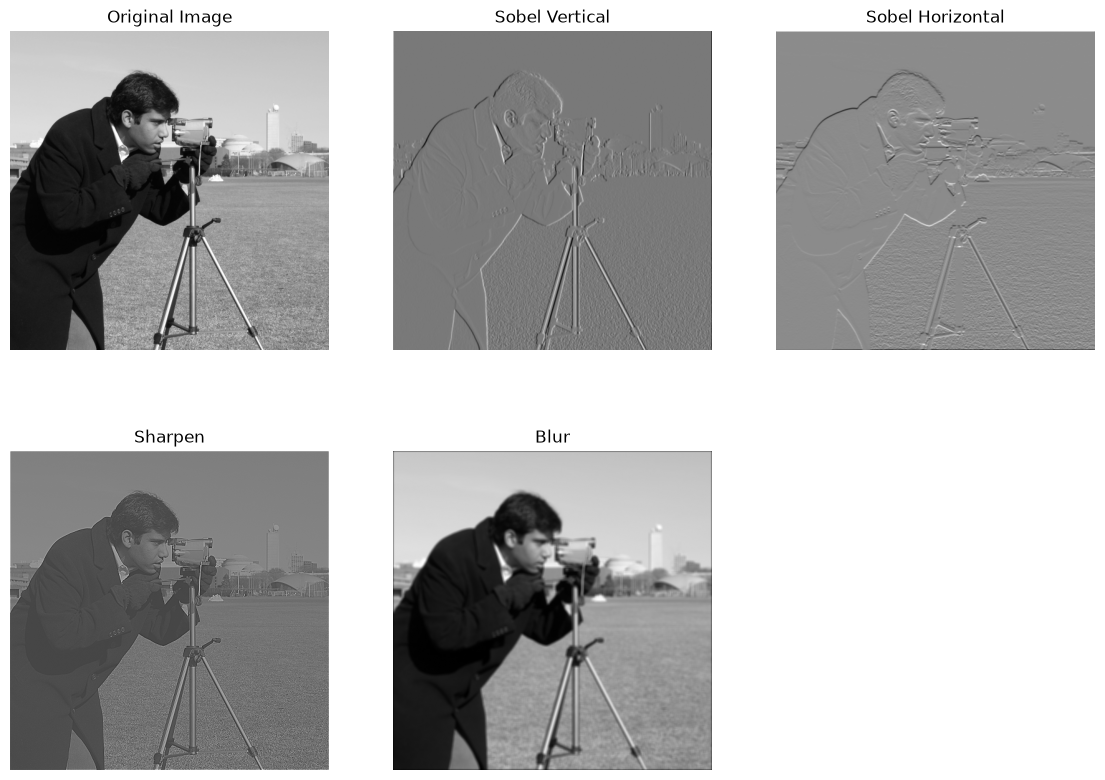

In [34]:
plt.figure(figsize=(14, 10))
plt.subplot(2, 3, 1)
plt.title("Original Image")
plt.imshow(gray_image, cmap='gray')
plt.axis('off')

plt.subplot(2, 3, 2)
plt.title("Sobel Vertical")
plt.imshow(feat_vertical, cmap='gray')
plt.axis('off')

plt.subplot(2, 3, 3)
plt.title("Sobel Horizontal")
plt.imshow(feat_horizontal, cmap='gray')
plt.axis('off')

plt.subplot(2, 3, 4)
plt.title("Sharpen")
plt.imshow(feat_sharpen, cmap='gray')
plt.axis('off')

plt.subplot(2, 3, 5)
plt.title("Blur")
plt.imshow(feat_blur, cmap='gray')
plt.axis('off')